In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [2]:
from sklearn.datasets import make_blobs


X, _ = make_blobs(
    n_samples=150,
    centers=3,
    cluster_std=1.2,
    random_state=42
)

df = pd.DataFrame(X, columns=["Feature_1", "Feature_2"])
df.head()

,Feature_1,Feature_2
0,-2.552189,10.891859
1,-3.516259,8.643231
2,-6.542437,-7.627349
3,6.903302,2.182663
4,-6.261585,-6.263566


In [26]:
import random
class KMeans:
    def __init__(self, n_clusters=2, max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None
    def fit_predict(self , x):
        random_index = random.sample(range(0, X.shape[0]) , self.n_clusters)
        self.centroids = x[random_index]

        for i in range(self.max_iter):
            #assign cluster
            cluster_group = self.assign_cluster(x)
            # move_centroid
            old_centroid = self.centroids
            self.centroids = self.move_centroid(x , cluster_group)
            # check finish
            if np.array_equal(old_centroid, self.centroids):
                break
        return cluster_group


    def assign_cluster(self, x):
        cluster_group = []
        distances = []
        for row in x:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row-centroid , row-centroid)))
            min_distance = min(distances)
            indx_position = distances.index(min_distance)
            cluster_group.append(indx_position)
            distances.clear()
        return np.array(cluster_group)

    def move_centroid(self , x ,cluster_group):
        new_centroid = []
        cluster_type = np.unique(cluster_group)
        for type in cluster_type: 
            new_centroid.append(x[cluster_group ==type].mean(axis=0))
        return np.array(new_centroid)
    
    def calculate_wss(self, x, cluster_group):
        wss = 0
        for i in range(self.n_clusters):
            cluster_points = x[cluster_group == i]
            wss += np.sum((cluster_points - self.centroids[i]) ** 2)
        return wss
    
    def elbow_method(self, x, max_k=10):
        wss = []
        K = range(1, max_k + 1)
        for k in K:
            kmeans = KMeans(n_clusters=k)
            cluster_group = kmeans.fit_predict(x)
            wss.append(kmeans.calculate_wss(x, cluster_group))

        plt.plot(K, wss, 'bo-')
        plt.xlabel('Number of clusters (k)')
        plt.ylabel('Within-cluster sum of squares (WSS)')
        plt.title('Elbow Method For Optimal k')
        plt.show()
    

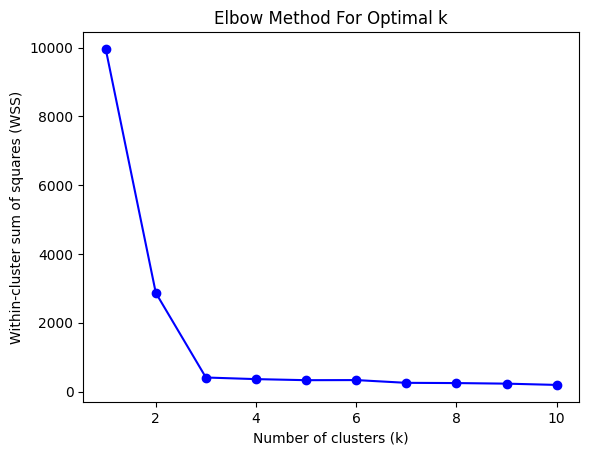

In [30]:
km = KMeans()
km.elbow_method(X)

In [31]:
km = KMeans(n_clusters=3, max_iter=100)
y_pred = km.fit_predict(X)

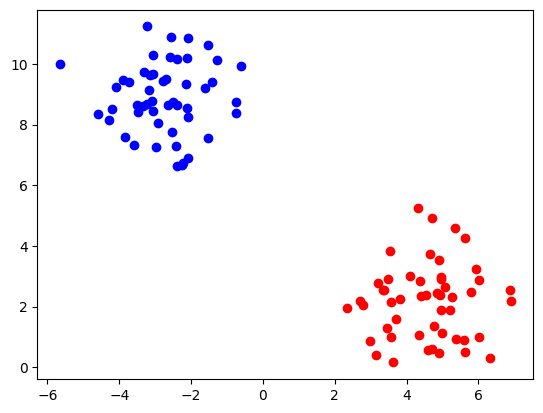

In [32]:
plt.scatter(X[y_pred == 0, 0], X[y_pred == 0, 1], color='blue')
plt.scatter(X[y_pred == 1, 0], X[y_pred == 1, 1], color='red')